In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/processed_reviews.csv")

In [4]:
df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience,Sentiment,Clean_Review,Sentiment_Label
0,Lisa,/users/63c2d28aff751c001470ce46,US,1 review,2023-01-14T18:41:59.000Z,1,What happened to quality customer service?,"I ordered several items on Jan 2, this review ...","January 14, 2023",Negative,ordered several item jan review reference retu...,0
1,J Ellery,/users/4f5291a30000640001153f96,GB,6 reviews,2012-03-03T21:50:56.000Z,5,Best on the web,Never any problems.goods always arrive when st...,"March 03, 2012",Positive,never problemsgoods always arrive stated exell...,2
2,Heather Weber,/users/5d37078e6614abe3ab453adf,US,1 review,2019-07-23T13:12:41.000Z,3,Issues with online purchases,"Recently, I have been having issues with my or...","July 23, 2019",Neutral,recently issue order receiving item order rece...,1
3,Mrs Lowe,/users/5666ab6d0000ff0001f14958,GB,2 reviews,2015-12-08T10:07:54.695Z,5,Excellent as always,Very good.,NaN,Positive,good,2
4,Lolo Paz,/users/5d8732fb681610d90db66d2e,US,2 reviews,2019-09-22T08:41:50.000Z,4,Ive been shopping with amazon for…,Ive been shopping with amazon for almost a yea...,"September 22, 2019",Positive,ive shopping amazon almost year get delivery a...,2


In [5]:
X = df['Clean_Review']

y = df['Sentiment_Label']

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [8]:
X_tfidf = tfidf.fit_transform(X)

In [9]:
X_tfidf.shape

(42739, 5000)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(

    X_tfidf,
    y,

    test_size=0.2,

    random_state=42

)

In [12]:
print(X_train.shape)

print(X_test.shape)

(34191, 5000)
(8548, 5000)


In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf_model = RandomForestClassifier()

In [15]:
rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
rf_model.score(
    X_train,
    y_train
)

0.9996782779093913

In [16]:
y_pred = rf_model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [40]:
df.Sentiment_Label.value_counts()

Sentiment_Label
2    17923
0    14348
1    10468
Name: count, dtype: int64

In [43]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average = "weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average = "weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average = "weighted"
)


accuracy, precision, recall, f1

(0.9401029480580253,
 0.9450418463103885,
 0.9401029480580253,
 0.9407391828708184)

In [19]:
from sklearn.metrics import classification_report

In [44]:
print(

    classification_report(
        y_test,
        y_pred
    )

)

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2828
           1       1.00      0.92      0.96      2102
           2       0.97      0.92      0.95      3618

    accuracy                           0.94      8548
   macro avg       0.95      0.94      0.94      8548
weighted avg       0.95      0.94      0.94      8548



In [21]:
from sklearn.metrics import confusion_matrix

In [22]:
cm = confusion_matrix(
    y_test,
    y_pred
)

In [23]:
print("Confusion Matrix:")

print(cm)

Confusion Matrix:
[[2774    1   53]
 [ 125 1940   37]
 [ 294    2 3322]]


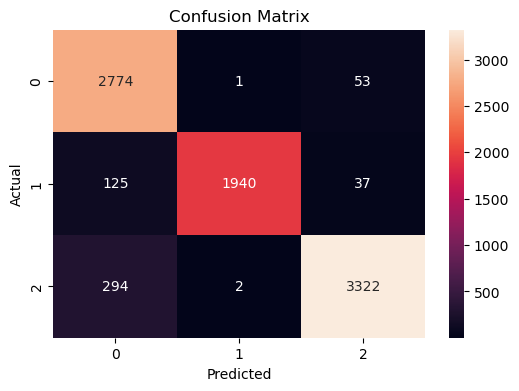

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
label_mapping = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("\nLabel Mapping:")

print(label_mapping)

sample_review = [
    "The delivery was excellent and very fast"
]

sample_vector = tfidf.transform(
    sample_review
)

prediction = rf_model.predict(
    sample_vector
)

predicted_sentiment = label_mapping[
    prediction[0]
]

print("\nCustom Review Prediction:")

print(predicted_sentiment)


Label Mapping:
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}


In [32]:
sample_review = [
    "The product is okay and average"
]

sample_vector = tfidf.transform(
    sample_review
)

prediction = rf_model.predict(
    sample_vector
)

predicted_sentiment = label_mapping[
    prediction[0]
]

print(predicted_sentiment)


Neutral


In [34]:
import pickle

with open(
    "../models/tfidf.pkl",
    "wb"
) as file:

    pickle.dump(
        tfidf,
        file
    )

In [35]:
with open(
    "../models/random_forest.pkl",
    "wb"
) as file:

    pickle.dump(
        rf_model,
        file
    )


In [46]:
compare = {
    "Actual": y_test,
    "Predicted":y_pred
}

compare = pd.DataFrame(compare)
compare.sample(10)

,Actual,Predicted
20574,0,0
26610,1,1
38742,1,1
3853,0,0
11206,0,0
41662,2,2
41068,2,2
22627,0,0
3028,1,1
41956,2,2
